In [1]:
import pickle
import pandas as pd
import numpy as np
import xidplus
import matplotlib.pyplot as plt


In [82]:
original_tile = 79695882

num = 2

for i in range(num-1):
    original_tile += 10

original = f"xid_checking_incomplete_priors_euclid_wide_v2.2_{num}_PRIMA_1A_1_coadd_tile{original_tile}_order12_large7.pkl"
missing = f"xid_checking_incomplete_priors_euclid_wide_v2.2_missing2_{num}_PRIMA_1A_1_coadd_tile{original_tile}_order12_large7.pkl"

In [83]:
with open(original, "rb") as f:
    data = pickle.load(f)

prior_og = data["prior"]
posterior_og = data["posterior"]

with open(missing, "rb") as f:
    data = pickle.load(f)

prior_mia = data["prior"]
posterior_mia = data["posterior"]

([<aplpy.core.FITSFigure at 0x76678d241370>],
 <Figure size 1000x1000 with 2 Axes>)

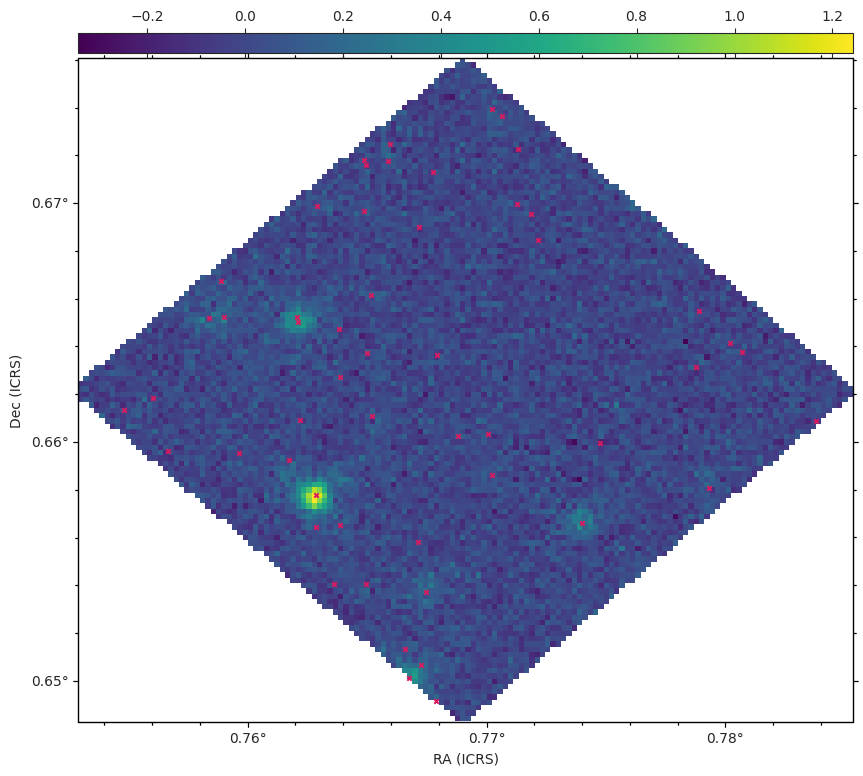

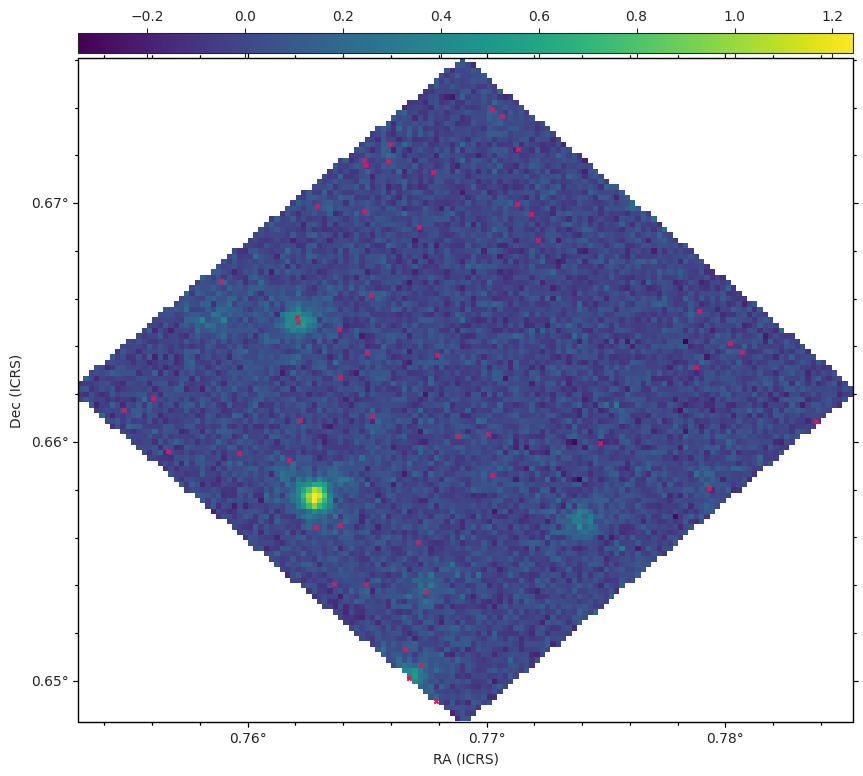

In [84]:
xidplus.plot_map([prior_og], False)

xidplus.plot_map([prior_mia], False)

([<aplpy.core.FITSFigure at 0x76678cfbfbc0>],
 <Figure size 1000x1000 with 2 Axes>)

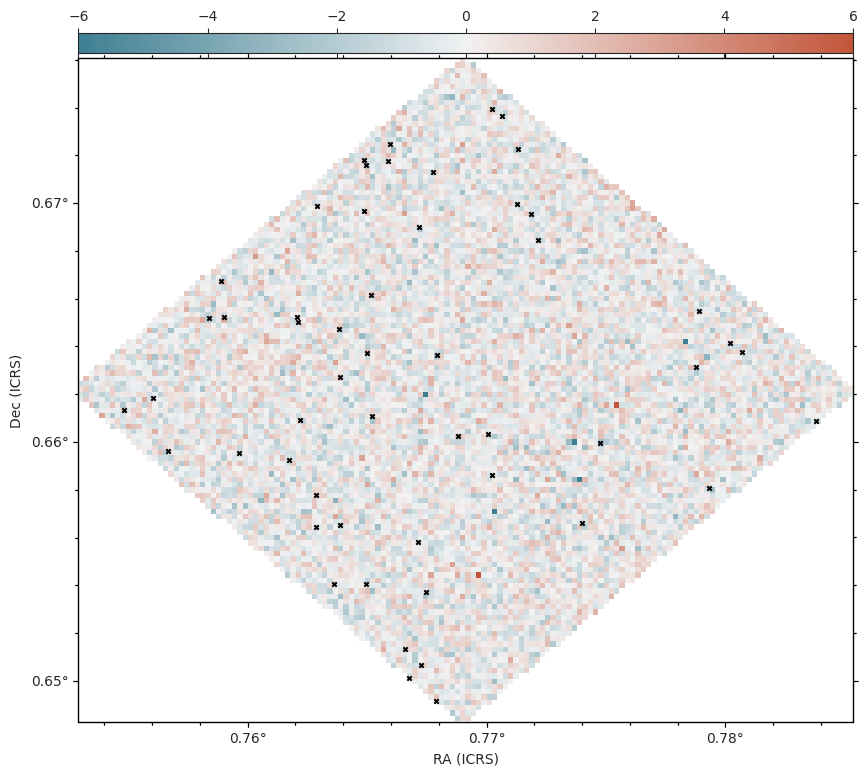

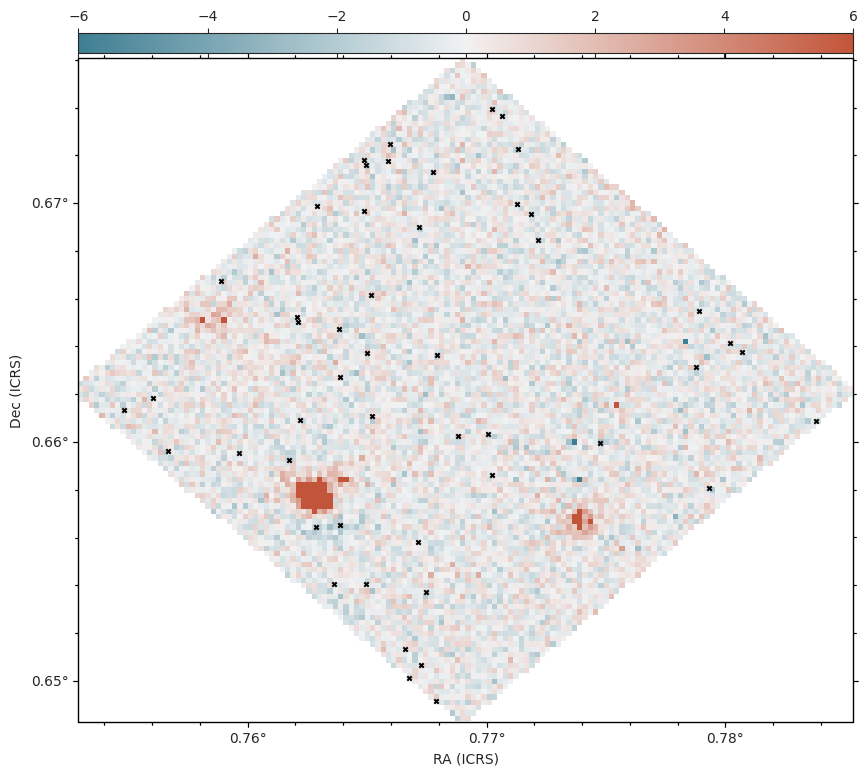

In [85]:
xidplus.plot_Bayes_pval_map([prior_og], posterior_og)

xidplus.plot_Bayes_pval_map([prior_mia], posterior_mia)

In [154]:
from xidplus import posterior_maps as postmaps

# prior = prior_og
prior = prior_mia
# posterior = posterior_og
posterior = posterior_mia


mod_map_array = postmaps.replicated_maps([prior], posterior, posterior.samples['src_f'].shape[0])
Bayes_pvals = postmaps.make_Bayesian_pval_maps(prior, mod_map_array[0])

In [155]:
ny = np.max(prior.sy_pix) - np.min(prior.sy_pix) + 1
nx = np.max(prior.sx_pix) - np.min(prior.sx_pix) + 1

In [156]:
sigma_map_2d = np.zeros((ny, nx))


In [157]:
y_idx = prior.sy_pix - np.min(prior.sy_pix)  # row indices
x_idx = prior.sx_pix - np.min(prior.sx_pix)  # column indices

sigma_map_2d[y_idx, x_idx] = Bayes_pvals

In [166]:
import seaborn as sns
cmap = sns.diverging_palette(220, 20, as_cmap=True)
cmap = plt.cm.get_cmap(cmap.name).copy()  # now it supports set_bad
cmap.set_bad(color='black')

/tmp/ipykernel_18907/977981809.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap.name).copy()  # now it supports set_bad


ValueError: 'blend' is not a valid value for name; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r'

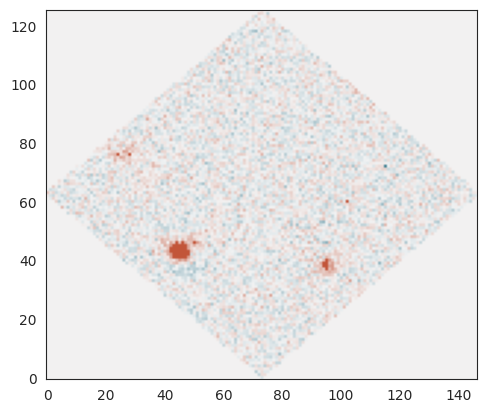

In [165]:
plt.imshow(sigma_map_2d, cmap = cmap, origin = "lower")

In [160]:
from astropy.io import fits
from xid_functions import *

pdf = fits.open("PRIMA_1A_1_coadd.fits")
pdf = pdf[0].data

In [161]:
from astropy.convolution import convolve_fft

convolved = convolve_fft(sigma_map_2d, pdf,
                         normalize_kernel = True,
                         nan_treatment = "fill")

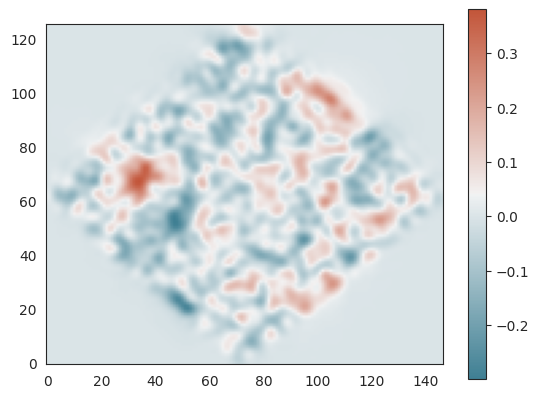

In [153]:
plt.imshow(convolved, cmap = cmap, origin = "lower")
plt.colorbar()

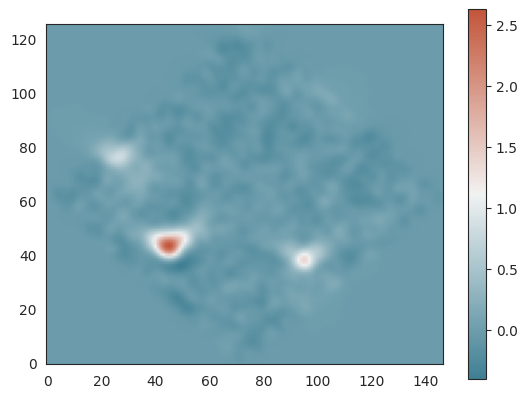

In [163]:
plt.imshow(convolved, cmap = cmap, origin = "lower")
plt.colorbar()